In [1]:
# Standard data science libraries
import pandas as pd  # Data manipulation
import numpy as np  # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Statistical visualizations

# scikit-learn utilities for modeling, preprocessing, and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings  # Control warning output in notebook

In [2]:
# Suppress non-critical warnings to keep notebook output clean
warnings.filterwarnings('ignore')

# Load the dataset containing best-selling albums
data = pd.read_csv('best_selling_albums.csv')

# Quick inspections to understand dataset shape and types
print("Dataset Shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nData Info:")
print(data.info())

Dataset Shape: (49, 7)

First 5 rows:
                       Album           Artist  Year  Sales_Millions Decade  \
0                   Thriller  Michael Jackson  1982              70  1980s   
1              Back in Black            AC/DC  1980              50  1980s   
2  The Dark Side of the Moon       Pink Floyd  1973              45  1970s   
3              The Bodyguard  Whitney Houston  1992              45  1990s   
4            Bat Out of Hell        Meat Loaf  1977              43  1970s   

     Country Genre  
0        USA   Pop  
1  Australia  Rock  
2         UK  Rock  
3        USA   Pop  
4        USA  Rock  

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Album           49 non-null     object
 1   Artist          49 non-null     object
 2   Year            49 non-null     int64 
 3   Sales_Millions  49 non-null 

In [4]:
# Basic Data Exploration
# Print basic summary statistics and check for missing values
print("\n=== DATA EXPLORATION ===")
print("\nSummary Statistics:")
print(data.describe())

print("\nMissing Values:")
print(data.isnull().sum())


=== DATA EXPLORATION ===

Summary Statistics:
              Year  Sales_Millions
count    49.000000       49.000000
mean   1988.306122       30.734694
std      13.731357        9.346959
min    1957.000000       20.000000
25%    1977.000000       24.000000
50%    1987.000000       28.000000
75%    1999.000000       33.000000
max    2017.000000       70.000000

Missing Values:
Album             0
Artist            0
Year              0
Sales_Millions    0
Decade            0
Country           0
Genre             0
dtype: int64


Text(0, 0.5, 'Frequency')

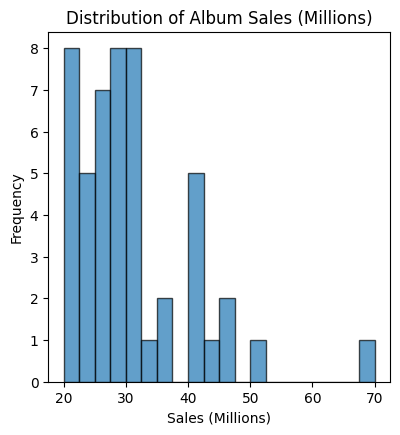

In [5]:
# Visualization: set up a larger figure for multiple subplots
plt.figure(figsize=(15, 10))

# 1. Sales distribution: histogram to inspect skew and outliers
plt.subplot(2, 3, 1)
plt.hist(data['Sales_Millions'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Album Sales (Millions)')
plt.xlabel('Sales (Millions)')
plt.ylabel('Frequency')

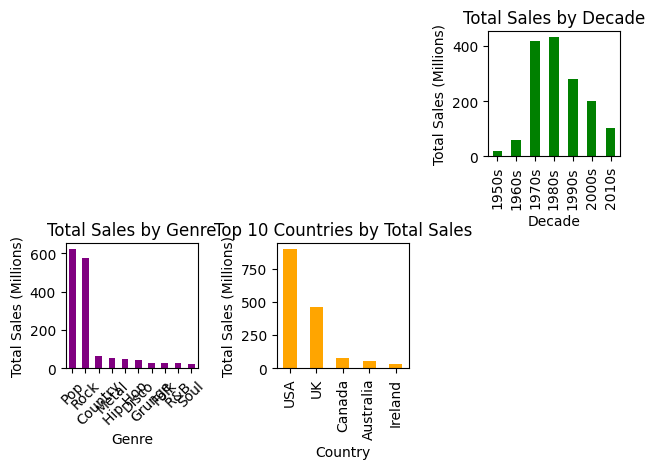


=== DATA PREPROCESSING ===
Genre encoded with 10 unique values
Country encoded with 5 unique values
Decade encoded with 7 unique values

Training set: (39, 4), Test set: (10, 4)

=== REGRESSION MODELS ===

Linear Regression:
  MAE: $8.14M
  RMSE: $9.77M
  R² Score: -5.625

Decision Tree:
  MAE: $4.70M
  RMSE: $6.76M
  R² Score: -2.171

Random Forest:
  MAE: $4.76M
  RMSE: $5.84M
  R² Score: -1.363

Gradient Boosting:
  MAE: $3.66M
  RMSE: $4.53M
  R² Score: -0.427

=== MODEL COMPARISON ===
                        MAE      RMSE        R2
Linear Regression  8.140715  9.770818 -5.625183
Decision Tree      4.700000  6.760178 -2.171409
Random Forest      4.764667  5.835453 -1.363117
Gradient Boosting  3.655957  4.534371 -0.426823

=== FEATURE IMPORTANCE ===
   Feature  Importance
0     Year    0.711446
3   Decade    0.102914
2  Country    0.094175
1    Genre    0.091465

=== CLUSTERING ANALYSIS ===


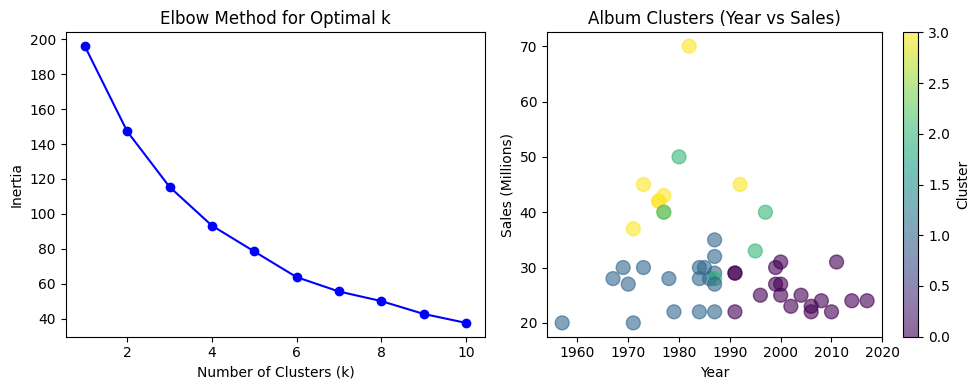


Cluster Analysis:

Cluster 0 (18 albums):
  Avg Sales: $25.7M
  Avg Year: 2002
  Most Common Genre: Pop
  Most Common Country: USA

Cluster 1 (18 albums):
  Avg Sales: $27.1M
  Avg Year: 1979
  Most Common Genre: Pop
  Most Common Country: USA

Cluster 2 (5 albums):
  Avg Sales: $38.2M
  Avg Year: 1987
  Most Common Genre: Rock
  Most Common Country: Canada

Cluster 3 (8 albums):
  Avg Sales: $45.5M
  Avg Year: 1978
  Most Common Genre: Rock
  Most Common Country: USA

=== PREDICTIVE ANALYSIS EXAMPLE ===
Predicted sales for a 2020 Pop album from USA: $31.9M

=== ADDITIONAL INSIGHTS ===


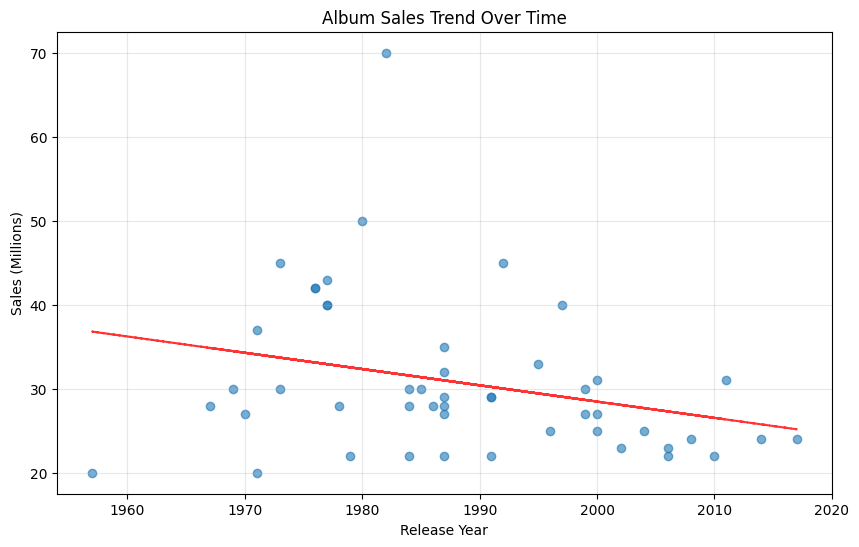


Top Performing Genre-Country Combinations:
Genre    Country  
Rock     Australia    50.000000
Country  Canada       40.000000
Disco    UK           40.000000
Rock     USA          33.714286
Pop      Canada       33.000000
Rock     UK           32.875000
Pop      USA          30.466667
Grunge   USA          29.000000
Rock     Ireland      28.000000
Folk     USA          27.000000
Name: Sales_Millions, dtype: float64

Success Factors Analysis:
Average sales by decade:
Decade
1970s    34.666667
1980s    33.153846
1990s    31.111111
1960s    29.000000
2010s    25.250000
2000s    25.000000
1950s    20.000000
Name: Sales_Millions, dtype: float64

Average sales by genre:
Genre
Disco      40.000000
Rock       33.941176
Country    32.000000
Pop        29.619048
Grunge     29.000000
Folk       27.000000
Metal      27.000000
R&B        25.000000
Soul       23.000000
Hip Hop    22.500000
Name: Sales_Millions, dtype: float64

Most productive years (top 5):
Year
1982    70.0
1980    50.0
1992    45

In [7]:
# 3. Sales by decade and additional visualizations
from sklearn import pipeline  # (unused import kept for reference if pipeline used later)

# Bar chart: total sales per decade
plt.subplot(2, 3, 3)
decade_sales = data.groupby('Decade')['Sales_Millions'].sum()
decade_sales.plot(kind='bar', color='green')
plt.title('Total Sales by Decade')
plt.xlabel('Decade')
plt.ylabel('Total Sales (Millions)')

# 4. Sales by genre: compare total sales across genres
plt.subplot(2, 3, 4)
genre_sales = data.groupby('Genre')['Sales_Millions'].sum().sort_values(ascending=False)
genre_sales.plot(kind='bar', color='purple')
plt.title('Total Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=45)

# 5. Sales by country: top 10 contributors
plt.subplot(2, 3, 5)
country_sales = data.groupby('Country')['Sales_Millions'].sum().sort_values(ascending=False).head(10)
country_sales.plot(kind='bar', color='orange')
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales (Millions)')

plt.tight_layout()
plt.show()

# Data Preprocessing for Machine Learning
print("\n=== DATA PREPROCESSING ===")

# Create a working copy for ML operations
data_ml = data.copy()

# Encode categorical variables using LabelEncoder for simplicity
label_encoders = {}
categorical_cols = ['Genre', 'Country', 'Decade']

for col in categorical_cols:
    le = LabelEncoder()
    data_ml[col] = le.fit_transform(data_ml[col])
    label_encoders[col] = le
    print(f"{col} encoded with {len(le.classes_)} unique values")

# Define features (X) and target (y)
X = data_ml[['Year', 'Genre', 'Country', 'Decade']]
y = data_ml['Sales_Millions']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set: {X_train.shape}, Test set: {X_test.shape}")

# Scale numerical features for algorithms that are sensitive to feature scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===== REGRESSION MODELS (Predicting Sales) =====
print("\n=== REGRESSION MODELS ===")

# Define a set of models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

# Train each model and evaluate on the test set
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions on the scaled test set
    y_pred = model.predict(X_test_scaled)
    
    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }
    
    print(f"\n{name}:")
    print(f"  MAE: ${mae:.2f}M")
    print(f"  RMSE: ${rmse:.2f}M")
    print(f"  R² Score: {r2:.3f}")

# Compare models in a DataFrame for easier inspection
print("\n=== MODEL COMPARISON ===")
results_df = pd.DataFrame(results).T
print(results_df)

# Feature Importance: fit a Random Forest on unscaled features to inspect importances
print("\n=== FEATURE IMPORTANCE ===")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

# ===== CLUSTERING ANALYSIS =====
print("\n=== CLUSTERING ANALYSIS ===")

# Prepare a subset of features for clustering
clustering_data = data_ml[['Year', 'Sales_Millions', 'Genre', 'Country']].copy()

# Standardize before clustering
scaler_cluster = StandardScaler()
clustering_scaled = scaler_cluster.fit_transform(clustering_data)

# Use the elbow method to choose a reasonable k
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(clustering_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

# Apply KMeans with 4 clusters (chosen from elbow)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(clustering_scaled)
data['Cluster'] = clusters

# Visualize clusters on Year vs Sales
plt.subplot(1, 2, 2)
scatter = plt.scatter(data['Year'], data['Sales_Millions'], 
                     c=data['Cluster'], cmap='viridis', s=100, alpha=0.6)
plt.xlabel('Year')
plt.ylabel('Sales (Millions)')
plt.title('Album Clusters (Year vs Sales)')
plt.colorbar(scatter, label='Cluster')

plt.tight_layout()
plt.show()

# Summarize cluster characteristics
print("\nCluster Analysis:")
for cluster_num in range(4):
    cluster_data = data[data['Cluster'] == cluster_num]
    print(f"\nCluster {cluster_num} ({len(cluster_data)} albums):")
    print(f"  Avg Sales: ${cluster_data['Sales_Millions'].mean():.1f}M")
    print(f"  Avg Year: {cluster_data['Year'].mean():.0f}")
    print(f"  Most Common Genre: {cluster_data['Genre'].mode().iloc[0]}")
    print(f"  Most Common Country: {cluster_data['Country'].mode().iloc[0]}")

# ===== PREDICTIVE ANALYSIS EXAMPLE =====
print("\n=== PREDICTIVE ANALYSIS EXAMPLE ===")

# Create a sample new album to predict (will be encoded and scaled)
new_album = pd.DataFrame({
    'Year': [2020],
    'Genre': ['Pop'],  # Will need to be encoded
    'Country': ['USA'],  # Will need to be encoded
    'Decade': ['2020s']  # Will need to be encoded
})

# Encode new album using the previously fitted LabelEncoders
for col in ['Genre', 'Country', 'Decade']:
    # Add the new category if it doesn't exist in the encoder
    if new_album[col].iloc[0] not in label_encoders[col].classes_:
        label_encoders[col].classes_ = np.append(label_encoders[col].classes_, new_album[col].iloc[0])
    new_album[col] = label_encoders[col].transform(new_album[col])

# Scale and predict using the trained Random Forest model
new_album_scaled = scaler.transform(new_album[X.columns])
predicted_sales = rf_model.predict(new_album_scaled)

print(f"Predicted sales for a 2020 Pop album from USA: ${predicted_sales[0]:.1f}M")

# ===== ADDITIONAL INSIGHTS =====
print("\n=== ADDITIONAL INSIGHTS ===")

# 1. Sales trends over time (simple linear fit)
plt.figure(figsize=(10, 6))
plt.scatter(data['Year'], data['Sales_Millions'], alpha=0.6)
z = np.polyfit(data['Year'], data['Sales_Millions'], 1)
p = np.poly1d(z)
plt.plot(data['Year'], p(data['Year']), "r--", alpha=0.8)
plt.xlabel('Release Year')
plt.ylabel('Sales (Millions)')
plt.title('Album Sales Trend Over Time')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Top performing Genre-Country combinations by average sales
print("\nTop Performing Genre-Country Combinations:")
genre_country_sales = data.groupby(['Genre', 'Country'])['Sales_Millions'].mean().sort_values(ascending=False).head(10)
print(genre_country_sales)

# 3. Success factors analysis: averages by decade, genre, year
print("\nSuccess Factors Analysis:")
print(f"Average sales by decade:")
decade_avg = data.groupby('Decade')['Sales_Millions'].mean().sort_values(ascending=False)
print(decade_avg)

print(f"\nAverage sales by genre:")
genre_avg = data.groupby('Genre')['Sales_Millions'].mean().sort_values(ascending=False)
print(genre_avg)

print(f"\nMost productive years (top 5):")
year_avg = data.groupby('Year')['Sales_Millions'].mean().sort_values(ascending=False).head(5)
print(year_avg)

# ===== RECOMMENDATION SYSTEM CONCEPT =====
print("\n=== RECOMMENDATION SYSTEM CONCEPT ===")

def find_similar_albums(album_name, n=5):
    """Find albums similar to the given album based on feature distance.

    This uses a simple Euclidean distance over the encoded feature space `X`.
    For a production system consider cosine similarity, feature weighting, and more features.
    """
    if album_name not in data['Album'].values:
        print(f"Album '{album_name}' not found in dataset.")
        return
    
    album_idx = data[data['Album'] == album_name].index[0]
    album_features = X.iloc[album_idx].values.reshape(1, -1)
    
    # Calculate similarity (Euclidean distance) to all other albums
    distances = []
    for i in range(len(X)):
        if i != album_idx:
            other_features = X.iloc[i].values.reshape(1, -1)
            distance = np.linalg.norm(album_features - other_features)
            distances.append((i, distance))
    
    # Sort by similarity (smallest distance first)
    distances.sort(key=lambda x: x[1])
    
    # Display the top n similar albums
    print(f"\nAlbums similar to '{album_name}':")
    for idx, dist in distances[:n]:
        similar_album = data.iloc[idx]
        print(f"  • {similar_album['Album']} by {similar_album['Artist']} ({similar_album['Year']})")
        print(f"    Genre: {similar_album['Genre']}, Sales: ${similar_album['Sales_Millions']}M")

# Example usage of the simple recommender
find_similar_albums("Thriller")
find_similar_albums("Nevermind")

print("\n=== ANALYSIS COMPLETE ===")